In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy as sc

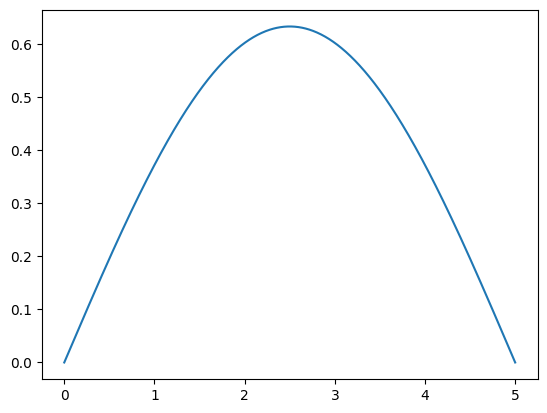

In [77]:
def psis(x, L, n):
    return np.sqrt(2/L) * np.sin(n * np.pi * x / L)

N = 1000
L = 5
x = np.linspace(0, L, N)
psi1 = psis(x, L, 1)
plt.plot(x, psi1, label='n=1')

In [78]:
def Energy(n, L):
    return (n**2 * np.pi**2) / (2 * L**2)

def integrand(x, n1, n2, L):
    return psis(x, L, n1) * psis(x, L, n2)

def inner_product(x, n1, n2, Hp, L):
    integral = np.trapz(integrand(x, n1, n2, L) * Hp, x)
    return integral

print("Inner product for n1=1, n2=2:", inner_product(x, 4, 1, Hp, L))

Inner product for n1=1, n2=2: 0.0


1.329824915528496

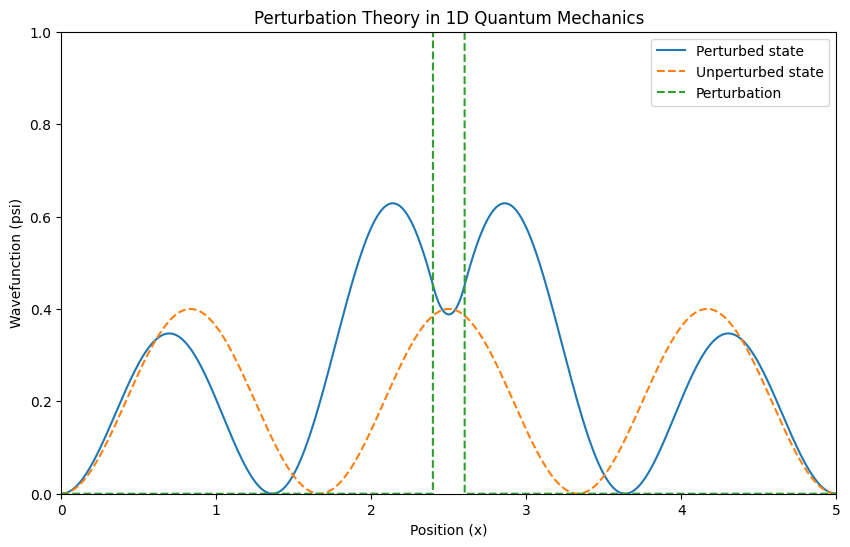

In [85]:
Hp = np.zeros(N)
mask = (x < 2.6) & (x > 2.4)  # Define the perturbation region
Hp[mask] = 10

psin = np.zeros(N)
m_iter = 1000
n = 3
psin += psis(x, L, n)  # Start with the unperturbed state
for m in range(m_iter):
    if (m + 1) != n:
        psin += inner_product(x, n, m+1, Hp, L) /(Energy(n, L) - Energy(m+1, L)) * psis(x, L, m+1)

plt.figure(figsize=(10, 6))
plt.title('Perturbation Theory in 1D Quantum Mechanics')
plt.xlabel('Position (x)')
plt.ylabel('Wavefunction (psi)')
plt.axis([0, L, 0, 1])
plt.plot(x, psin**2, label='Perturbed state')
plt.plot(x, psis(x, L, n)**2, label='Unperturbed state', linestyle='--') 
plt.plot(x, Hp, label='Perturbation', linestyle='--')
plt.legend()
np.trapz(psin**2, x)  # Normalization check

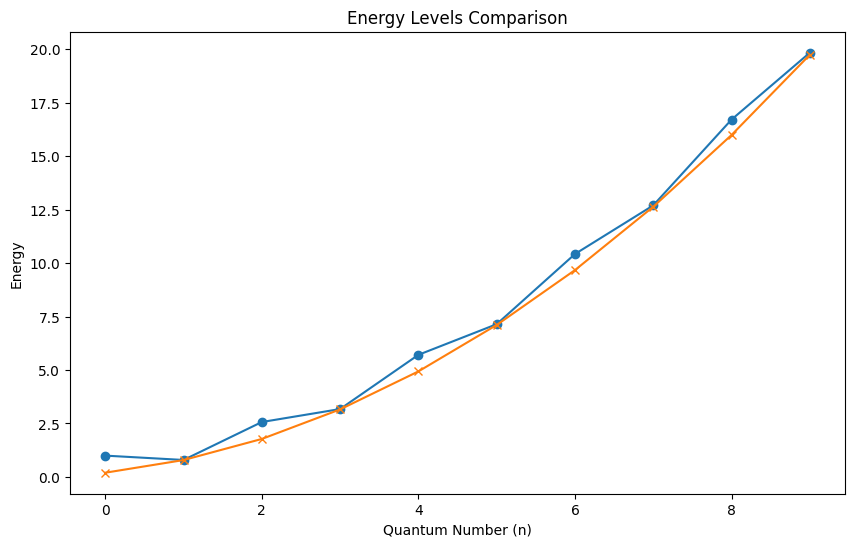

In [83]:
num_levels = 10
Energy_perturbed = np.fromiter(((Energy(i+1, L) + np.trapz(integrand(x, i+1, i+1, L) * Hp, x)) for i in range(num_levels)), dtype=float)
Energy_unperturbed = np.fromiter((Energy(i+1, L) for i in range(num_levels)), dtype=float)
plt.figure(figsize=(10, 6))
plt.title('Energy Levels Comparison')
plt.xlabel('Quantum Number (n)')
plt.ylabel('Energy')
plt.plot(range(num_levels), Energy_perturbed, label='Perturbed Energy Levels', marker='o')
plt.plot(range(num_levels), Energy_unperturbed, label='Unperturbed Energy Levels', marker='x')